In [1]:
import pandas as pd

file_path = "./Dataset_and_Description/Oxy-files/oxy1.csv"
df = pd.read_csv(file_path)

# Drop the fake index column if it exists
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(df.shape)
df.head()


(3448, 20)


,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,ch9,ch10,ch11,ch12,ch13,ch14,ch15,ch16,ch17,ch18,ch19,ch20
0,0.000011,-0.000017,-0.000013,0.000013,-0.000004,0.000007,-0.000012,-0.000009,-0.000013,0.000009,7.420000e-07,-0.000008,-0.000018,-0.000002,-0.000021,0.000010,-0.000011,-0.000009,0.000011,-0.000040
1,0.000016,-0.000005,-0.000010,0.000027,0.000003,0.000032,0.000012,-0.000022,0.000003,0.000027,-9.800000e-07,0.000002,-0.000010,0.000009,-0.000018,0.000021,0.000005,0.000006,0.000023,-0.000029
2,0.000021,0.000007,-0.000006,0.000039,0.000010,0.000056,0.000036,-0.000034,0.000018,0.000044,-3.050000e-06,0.000013,-0.000003,0.000020,-0.000015,0.000031,0.000021,0.000021,0.000034,-0.000019
3,0.000026,0.000018,-0.000001,0.000051,0.000016,0.000078,0.000057,-0.000045,0.000032,0.000061,-5.770000e-06,0.000023,0.000004,0.000031,-0.000012,0.000041,0.000035,0.000034,0.000045,-0.000010
4,0.000031,0.000028,0.000004,0.000062,0.000021,0.000100,0.000076,-0.000055,0.000045,0.000076,-9.390000e-06,0.000032,0.000011,0.000041,-0.000009,0.000050,0.000048,0.000046,0.000055,-0.000001


In [2]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt

fs = 10.1725  # ✅ CONFIRMED from dataset

def bandpass_filter(data, fs, low=0.01, high=0.2, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, data)


df_filtered = df.copy()
for col in df.columns:
    df_filtered[col] = bandpass_filter(df[col].values, fs)

# Motion smoothing (recommended)
df_filtered = df_filtered.rolling(window=5, center=True).median()
df_filtered = df_filtered.dropna()

# df_filtered.to_csv("subject1_filtered.csv", index=False)

In [3]:
fs = 10.1725  # Hz (samples per second)
n_samples = len(df_filtered)
duration_sec = n_samples / fs
print("Total duration (sec) ≈", duration_sec)


Total duration (sec) ≈ 338.5598427131974


In [4]:
import numpy as np

fs = 10.1725
n_samples = len(df_filtered)

labels = np.zeros(n_samples, dtype=int)  # 0 = rest by default

# initial 30 sec rest → already 0, so we start grip after that
idx = int(30 * fs)   # sample index where first grip starts

for trial in range(10):
    # grip: 10 sec
    grip_start = idx
    grip_end = idx + int(10 * fs)
    
    # make sure we don't go beyond available samples
    grip_start = min(grip_start, n_samples)
    grip_end   = min(grip_end, n_samples)
    
    labels[grip_start:grip_end] = 1  # mark as grip
    
    # then 20 sec rest
    idx = grip_end + int(20 * fs)
    
    if idx >= n_samples:
        break  # no more data

# Attach this to your DataFrame
df_filtered["state"] = labels


In [5]:
df_filtered.head()

,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,ch9,ch10,...,ch12,ch13,ch14,ch15,ch16,ch17,ch18,ch19,ch20,state
2,0.000020,-1.640892e-05,0.000017,0.000133,0.000046,0.000211,0.000050,-0.000051,0.000050,0.000083,...,-0.000009,0.000026,0.000072,0.000080,0.000074,0.000046,0.000098,0.000049,0.000016,0
3,0.000025,-1.068728e-05,0.000024,0.000142,0.000049,0.000228,0.000060,-0.000053,0.000060,0.000092,...,-0.000004,0.000032,0.000080,0.000087,0.000083,0.000053,0.000105,0.000056,0.000021,0
4,0.000031,-5.042256e-06,0.000032,0.000150,0.000053,0.000245,0.000070,-0.000056,0.000069,0.000102,...,0.000001,0.000038,0.000088,0.000094,0.000092,0.000060,0.000112,0.000063,0.000025,0
5,0.000036,4.989277e-07,0.000039,0.000158,0.000056,0.000262,0.000080,-0.000058,0.000078,0.000111,...,0.000007,0.000043,0.000096,0.000101,0.000100,0.000067,0.000118,0.000070,0.000030,0
6,0.000040,5.910825e-06,0.000047,0.000166,0.000060,0.000279,0.000089,-0.000059,0.000088,0.000120,...,0.000012,0.000049,0.000103,0.000108,0.000109,0.000074,0.000125,0.000077,0.000034,0


In [6]:
df_filtered.shape

(3444, 21)

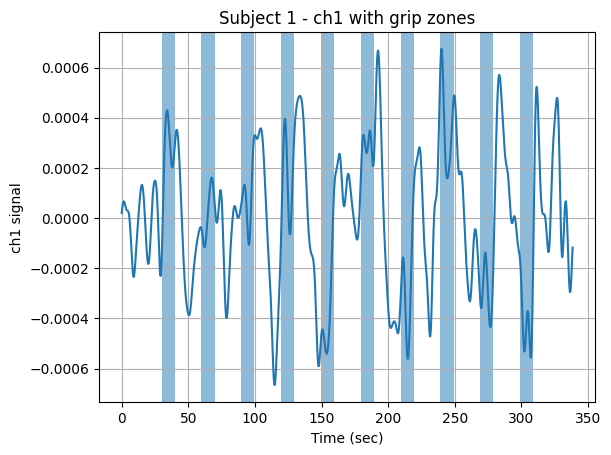

In [7]:
import matplotlib.pyplot as plt
import numpy as np

time = np.arange(len(df_filtered)) / fs

plt.figure()
plt.plot(time, df_filtered["ch1"])
plt.xlabel("Time (sec)")
plt.ylabel("ch1 signal")
plt.title("Subject 1 - ch1 with grip zones")
plt.grid(True)

# shade grip regions using the state array
in_grip = False
start = 0

for i in range(n_samples):
    if not in_grip and labels[i] == 1:
        in_grip = True
        start = time[i]
    elif in_grip and labels[i] == 0:
        in_grip = False
        end = time[i]
        plt.axvspan(start, end, alpha=0.5)  # shaded grip block

plt.show()


In [8]:
import numpy as np
import pandas as pd

fs = 10.1725
signal = df_filtered["ch1"].values
state = df_filtered["state"].values

features = []

idx = int(30 * fs)   # skip initial 30 sec rest

for trial in range(10):
    
    # ---------- GRIP ----------
    grip_start = idx
    grip_end = idx + int(10 * fs)

    grip_start = min(grip_start, len(signal))
    grip_end   = min(grip_end, len(signal))

    grip_seg = signal[grip_start:grip_end]

    if len(grip_seg) > 0:
        features.append({
            "State": 1,   # 1 = Grip
            "Mean": np.mean(grip_seg),
            "Std":  np.std(grip_seg),
            "Energy": np.sum(grip_seg ** 2),
            "RMS": np.sqrt(np.mean(grip_seg ** 2))
        })

    # ---------- REST ----------
    rest_start = grip_end
    rest_end = rest_start + int(20 * fs)

    rest_start = min(rest_start, len(signal))
    rest_end   = min(rest_end, len(signal))

    rest_seg = signal[rest_start:rest_end]

    if len(rest_seg) > 0:
        features.append({
            "State": 0,   # 0 = Rest
            "Mean": np.mean(rest_seg),
            "Std":  np.std(rest_seg),
            "Energy": np.sum(rest_seg ** 2),
            "RMS": np.sqrt(np.mean(rest_seg ** 2))
        })

    idx = rest_end
    if idx >= len(signal):
        break

# ✅ FINAL FEATURE TABLE
feature_df = pd.DataFrame(features)
feature_df


,State,Mean,Std,Energy,RMS
0,1,0.000254,0.000145,0.000009,0.000293
1,0,-0.000087,0.000234,0.000013,0.000250
2,1,0.000022,0.000102,0.000001,0.000104
3,0,-0.000063,0.000149,0.000005,0.000162
4,1,0.000081,0.000119,0.000002,0.000144
5,0,-0.000074,0.000362,0.000028,0.000370
6,1,0.000158,0.000155,0.000005,0.000221
7,0,0.000045,0.000372,0.000029,0.000375
8,1,-0.000376,0.000188,0.000018,0.000420
9,0,0.000096,0.000100,0.000004,0.000139


In [9]:
import numpy as np

# ✅ Make sure only channel columns are used (ch1 → ch20)
channel_data = df_filtered.iloc[:, :20]   # assumes first 20 columns are channels

# ✅ Mean of each row across 20 channels
df_filtered["Mean_Row"] = channel_data.mean(axis=1)

# ✅ Standard deviation of each row across 20 channels
df_filtered["Std_Row"] = channel_data.std(axis=1)

# ✅ Energy of each row across 20 channels
df_filtered["Energy_Row"] = (channel_data ** 2).sum(axis=1)

# ✅ RMS of each row across 20 channels
df_filtered["RMS_Row"] = np.sqrt((channel_data ** 2).mean(axis=1))

# ✅ Check result
df_filtered.head(100)


,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,ch9,ch10,...,ch16,ch17,ch18,ch19,ch20,state,Mean_Row,Std_Row,Energy_Row,RMS_Row
2,0.000020,-1.640892e-05,0.000017,0.000133,0.000046,0.000211,0.000050,-0.000051,0.000050,0.000083,...,0.000074,0.000046,0.000098,0.000049,0.000016,0,0.000050,0.000057,1.121607e-07,0.000075
3,0.000025,-1.068728e-05,0.000024,0.000142,0.000049,0.000228,0.000060,-0.000053,0.000060,0.000092,...,0.000083,0.000053,0.000105,0.000056,0.000021,0,0.000056,0.000061,1.336913e-07,0.000082
4,0.000031,-5.042256e-06,0.000032,0.000150,0.000053,0.000245,0.000070,-0.000056,0.000069,0.000102,...,0.000092,0.000060,0.000112,0.000063,0.000025,0,0.000063,0.000064,1.575226e-07,0.000089
5,0.000036,4.989277e-07,0.000039,0.000158,0.000056,0.000262,0.000080,-0.000058,0.000078,0.000111,...,0.000100,0.000067,0.000118,0.000070,0.000030,0,0.000069,0.000068,1.835628e-07,0.000096
6,0.000040,5.910825e-06,0.000047,0.000166,0.000060,0.000279,0.000089,-0.000059,0.000088,0.000120,...,0.000109,0.000074,0.000125,0.000077,0.000034,0,0.000076,0.000071,2.117000e-07,0.000103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,-0.000229,2.644335e-06,-0.000074,-0.000058,-0.000120,0.000037,0.000137,-0.000065,-0.000014,-0.000119,...,0.000179,-0.000059,-0.000140,0.000078,0.000128,0,-0.000027,0.000101,2.079870e-07,0.000102
98,-0.000225,4.224480e-06,-0.000074,-0.000056,-0.000117,0.000042,0.000137,-0.000064,-0.000014,-0.000118,...,0.000183,-0.000058,-0.000140,0.000082,0.000134,0,-0.000025,0.000102,2.085856e-07,0.000102
99,-0.000221,5.988288e-06,-0.000074,-0.000054,-0.000114,0.000047,0.000137,-0.000063,-0.000013,-0.000116,...,0.000188,-0.000057,-0.000140,0.000086,0.000140,0,-0.000023,0.000102,2.088907e-07,0.000102
100,-0.000217,7.934698e-06,-0.000074,-0.000052,-0.000110,0.000051,0.000138,-0.000062,-0.000012,-0.000115,...,0.000193,-0.000055,-0.000140,0.000091,0.000145,0,-0.000021,0.000103,2.089146e-07,0.000102


In [10]:
df.head(400)


,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,ch9,ch10,ch11,ch12,ch13,ch14,ch15,ch16,ch17,ch18,ch19,ch20
0,0.000011,-0.000017,-0.000013,0.000013,-0.000004,0.000007,-0.000012,-0.000009,-0.000013,0.000009,7.420000e-07,-0.000008,-0.000018,-0.000002,-0.000021,0.000010,-0.000011,-0.000009,0.000011,-0.000040
1,0.000016,-0.000005,-0.000010,0.000027,0.000003,0.000032,0.000012,-0.000022,0.000003,0.000027,-9.800000e-07,0.000002,-0.000010,0.000009,-0.000018,0.000021,0.000005,0.000006,0.000023,-0.000029
2,0.000021,0.000007,-0.000006,0.000039,0.000010,0.000056,0.000036,-0.000034,0.000018,0.000044,-3.050000e-06,0.000013,-0.000003,0.000020,-0.000015,0.000031,0.000021,0.000021,0.000034,-0.000019
3,0.000026,0.000018,-0.000001,0.000051,0.000016,0.000078,0.000057,-0.000045,0.000032,0.000061,-5.770000e-06,0.000023,0.000004,0.000031,-0.000012,0.000041,0.000035,0.000034,0.000045,-0.000010
4,0.000031,0.000028,0.000004,0.000062,0.000021,0.000100,0.000076,-0.000055,0.000045,0.000076,-9.390000e-06,0.000032,0.000011,0.000041,-0.000009,0.000050,0.000048,0.000046,0.000055,-0.000001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.000220,0.000239,0.000443,-0.000041,0.000156,-0.000108,0.000154,0.000438,0.000516,0.000199,6.980000e-05,0.000206,0.000250,-0.000116,0.000271,0.000060,0.000202,0.000209,0.000142,0.000137
396,0.000224,0.000237,0.000443,-0.000035,0.000159,-0.000111,0.000158,0.000445,0.000518,0.000202,6.450000e-05,0.000208,0.000251,-0.000118,0.000269,0.000068,0.000202,0.000205,0.000145,0.000142
397,0.000230,0.000236,0.000445,-0.000028,0.000162,-0.000112,0.000162,0.000454,0.000521,0.000205,5.910000e-05,0.000211,0.000252,-0.000119,0.000267,0.000078,0.000201,0.000201,0.000148,0.000148
398,0.000236,0.000234,0.000448,-0.000021,0.000166,-0.000112,0.000165,0.000463,0.000523,0.000210,5.390000e-05,0.000213,0.000253,-0.000120,0.000264,0.000087,0.000199,0.000195,0.000151,0.000154


In [11]:

base_path = "./Dataset_and_Description/Oxy-files/"
fs = 10.1725   # sampling rate

# Male subjects based on your folder info
male_subject_ids = [2, 9, 10, 11, 13, 14, 15, 18, 19, 20]

In [12]:
def create_state_labels(n_samples, fs):
    labels = np.zeros(n_samples, dtype=int)  # 0 = Rest
    
    idx = int(30 * fs)   # start after initial 30 sec rest
    
    for _ in range(10):
        grip_start = idx
        grip_end = idx + int(10 * fs)
        
        grip_start = min(grip_start, n_samples)
        grip_end   = min(grip_end, n_samples)
        
        labels[grip_start:grip_end] = 1  # Grip = 1
        
        idx = grip_end + int(20 * fs)
        if idx >= n_samples:
            break
    
    return labels


In [13]:
final_dfs = []

for subject_id in range(1, 21):   # oxy1 → oxy20
    
    # ---------- READ FILE ----------
    file_path = f"{base_path}oxy{subject_id}.csv"
    df = pd.read_csv(file_path)
    
    # ---------- CLEAN ----------
    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])

    df_filtered = df.copy()
    for col in df.columns:
        df[col] = bandpass_filter(df[col].values, fs)

    df = df.rolling(window=5, center=True).median()
    df = df.dropna()
    
    # ---------- CREATE STATE ----------
    state = create_state_labels(len(df), fs)
    df["State"] = state
    
    # ---------- ROW-WISE FEATURES ACROSS 20 CHANNELS ----------
    channel_data = df.iloc[:, :20]   # ch1 → ch20
    
    df["Mean_Row"]   = channel_data.mean(axis=1)
    df["Std_Row"]    = channel_data.std(axis=1)
    df["Energy_Row"] = (channel_data ** 2).sum(axis=1)
    df["RMS_Row"]    = np.sqrt((channel_data ** 2).mean(axis=1))
    
    # ---------- ADD GENDER ----------
    if subject_id in male_subject_ids:
        df["Gender"] = 1   # Male
    else:
        df["Gender"] = 0   # Female
    
    # ---------- KEEP ONLY FINAL COLUMNS ----------
    final_df = df[[
        "Mean_Row",
        "Std_Row",
        "Energy_Row",
        "RMS_Row",
        "State",
        "Gender"
    ]]
    
    final_dfs.append(df)


In [14]:
final_dataset = pd.concat(final_dfs, ignore_index=True)

print("✅ FINAL DATASET SHAPE:", final_dataset.shape)
final_dataset.head()


✅ FINAL DATASET SHAPE: (68880, 26)


,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,ch9,ch10,...,ch17,ch18,ch19,ch20,State,Mean_Row,Std_Row,Energy_Row,RMS_Row,Gender
0,0.000020,-1.640892e-05,0.000017,0.000133,0.000046,0.000211,0.000050,-0.000051,0.000050,0.000083,...,0.000046,0.000098,0.000049,0.000016,0,0.000050,0.000057,1.121607e-07,0.000075,0
1,0.000025,-1.068728e-05,0.000024,0.000142,0.000049,0.000228,0.000060,-0.000053,0.000060,0.000092,...,0.000053,0.000105,0.000056,0.000021,0,0.000056,0.000061,1.336913e-07,0.000082,0
2,0.000031,-5.042256e-06,0.000032,0.000150,0.000053,0.000245,0.000070,-0.000056,0.000069,0.000102,...,0.000060,0.000112,0.000063,0.000025,0,0.000063,0.000064,1.575226e-07,0.000089,0
3,0.000036,4.989277e-07,0.000039,0.000158,0.000056,0.000262,0.000080,-0.000058,0.000078,0.000111,...,0.000067,0.000118,0.000070,0.000030,0,0.000069,0.000068,1.835628e-07,0.000096,0
4,0.000040,5.910825e-06,0.000047,0.000166,0.000060,0.000279,0.000089,-0.000059,0.000088,0.000120,...,0.000074,0.000125,0.000077,0.000034,0,0.000076,0.000071,2.117000e-07,0.000103,0


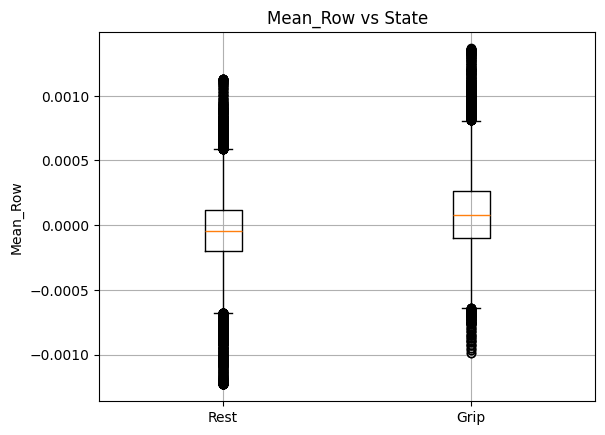

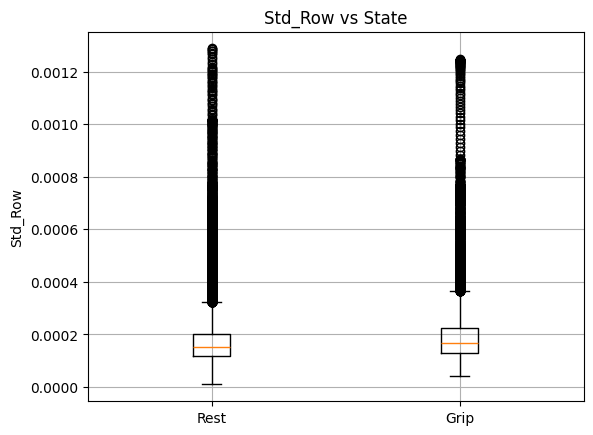

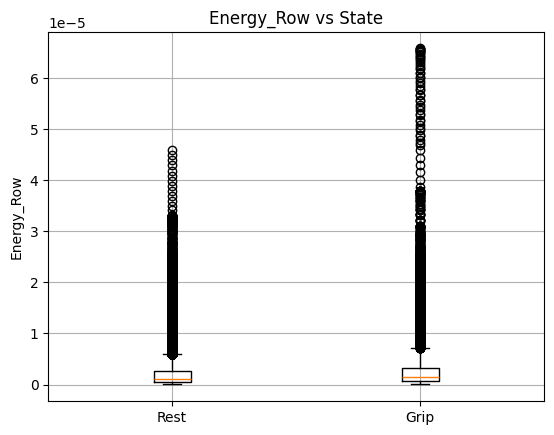

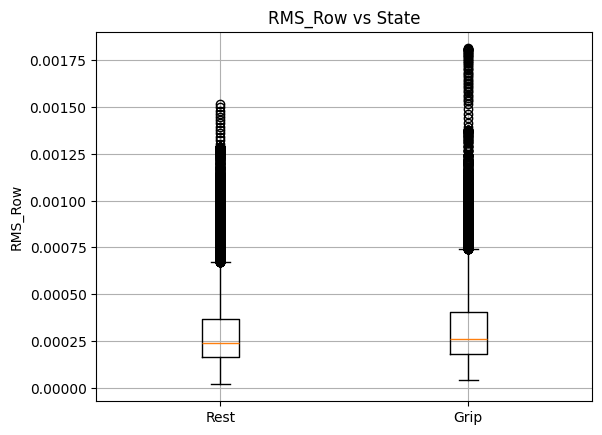

In [15]:
import matplotlib.pyplot as plt

rest_df = final_dataset[final_dataset["State"] == 0]
grip_df = final_dataset[final_dataset["State"] == 1]

# ---- Mean_Row vs State ----
plt.figure()
plt.boxplot([rest_df["Mean_Row"], grip_df["Mean_Row"]])
plt.xticks([1, 2], ["Rest", "Grip"])
plt.title("Mean_Row vs State")
plt.ylabel("Mean_Row")
plt.grid(True)
plt.show()

# ---- Std_Row vs State ----
plt.figure()
plt.boxplot([rest_df["Std_Row"], grip_df["Std_Row"]])
plt.xticks([1, 2], ["Rest", "Grip"])
plt.title("Std_Row vs State")
plt.ylabel("Std_Row")
plt.grid(True)
plt.show()

# ---- Energy_Row vs State ----
plt.figure()
plt.boxplot([rest_df["Energy_Row"], grip_df["Energy_Row"]])
plt.xticks([1, 2], ["Rest", "Grip"])
plt.title("Energy_Row vs State")
plt.ylabel("Energy_Row")
plt.grid(True)
plt.show()

# ---- RMS_Row vs State ----
plt.figure()
plt.boxplot([rest_df["RMS_Row"], grip_df["RMS_Row"]])
plt.xticks([1, 2], ["Rest", "Grip"])
plt.title("RMS_Row vs State")
plt.ylabel("RMS_Row")
plt.grid(True)
plt.show()


In [16]:
female_rest = final_dataset[(final_dataset["Gender"] == 0) & (final_dataset["State"] == 0)]
female_grip = final_dataset[(final_dataset["Gender"] == 0) & (final_dataset["State"] == 1)]

male_rest   = final_dataset[(final_dataset["Gender"] == 1) & (final_dataset["State"] == 0)]
male_grip   = final_dataset[(final_dataset["Gender"] == 1) & (final_dataset["State"] == 1)]


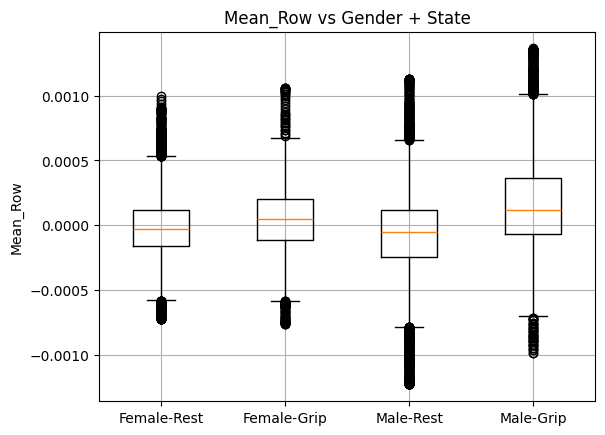

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot([
    female_rest["Mean_Row"],
    female_grip["Mean_Row"],
    male_rest["Mean_Row"],
    male_grip["Mean_Row"]
])

plt.xticks([1, 2, 3, 4], ["Female-Rest", "Female-Grip", "Male-Rest", "Male-Grip"])
plt.title("Mean_Row vs Gender + State")
plt.ylabel("Mean_Row")
plt.grid(True)
plt.show()


In [18]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

# =========================
# ✅ SETTINGS
# =========================

base_path = "./Dataset_and_Description/Oxy-files/"
fs = 10.1725   # sampling rate

male_subject_ids = [2, 9, 10, 11, 13, 14, 15, 18, 19, 20]

# =========================
# ✅ FUNCTION: CREATE STATE LABEL
# =========================

def create_state_labels(n_samples, fs):
    labels = np.zeros(n_samples, dtype=int)  # 0 = Rest
    
    idx = int(30 * fs)   # start after initial 30 sec rest
    
    for _ in range(10):
        grip_start = idx
        grip_end = idx + int(10 * fs)
        
        grip_start = min(grip_start, n_samples)
        grip_end   = min(grip_end, n_samples)
        
        labels[grip_start:grip_end] = 1  # Grip = 1
        
        idx = grip_end + int(20 * fs)
        if idx >= n_samples:
            break
    
    return labels

# =========================
# ✅ MAIN PIPELINE
# =========================

final_dfs = []
only_features=[]

for subject_id in range(1, 21):   # oxy1 → oxy20
    
    # ---------- READ FILE ----------
    file_path = f"{base_path}oxy{subject_id}.csv"
    df = pd.read_csv(file_path)
    
    # ---------- CLEAN ----------
    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])

    # df_filtered = df.copy()
    for col in df.columns:
        df[col] = bandpass_filter(df[col].values, fs)

    df = df.rolling(window=5, center=True).median()
    df = df.dropna()
    
    # ---------- SELECT CHANNELS SAFELY ----------
    channel_cols = [col for col in df.columns if col.startswith("ch")]
    channel_data = df[channel_cols]
    
    # ---------- ✅ Z-SCORE NORMALIZATION (PER CHANNEL, PER SUBJECT) ----------
    channel_data_z = channel_data.apply(zscore)
    
    # ---------- ✅ CREATE STATE ----------
    df["State"] = create_state_labels(len(df), fs)
    
    # ---------- ✅ ROW-WISE FEATURES (ON NORMALIZED DATA) ----------
    df["Mean_Row"]   = channel_data_z.mean(axis=1)
    df["Std_Row"]    = channel_data_z.std(axis=1)
    df["Energy_Row"] = (channel_data_z ** 2).sum(axis=1)
    df["RMS_Row"]    = np.sqrt((channel_data_z ** 2).mean(axis=1))
    
    # ---------- ✅ ADD GENDER ----------
    if subject_id in male_subject_ids:
        df["Gender"] = 1   # Male
    else:
        df["Gender"] = 0   # Female
    
    # ---------- ✅ KEEP ONLY FINAL ML COLUMNS ----------
    final_df = df[[
        "Mean_Row",
        "Std_Row",
        "Energy_Row",
        "RMS_Row",
        "State",
        "Gender"
    ]]
    
    final_dfs.append(df)
    only_features.append(final_df)


# =========================
# ✅ STACK ALL SUBJECTS
# =========================

final_dataset = pd.concat(final_dfs, ignore_index=True)

print("✅ FINAL DATASET SHAPE:", final_dataset.shape)
final_dataset.head(300)


✅ FINAL DATASET SHAPE: (68880, 26)


,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,ch9,ch10,...,ch17,ch18,ch19,ch20,State,Mean_Row,Std_Row,Energy_Row,RMS_Row,Gender
0,0.000020,-1.640892e-05,0.000017,0.000133,0.000046,0.000211,0.000050,-0.000051,0.000050,0.000083,...,0.000046,0.000098,0.000049,0.000016,0,0.252200,0.282903,2.792748,0.373681,0
1,0.000025,-1.068728e-05,0.000024,0.000142,0.000049,0.000228,0.000060,-0.000053,0.000060,0.000092,...,0.000053,0.000105,0.000056,0.000021,0,0.286123,0.299843,3.345541,0.408995,0
2,0.000031,-5.042256e-06,0.000032,0.000150,0.000053,0.000245,0.000070,-0.000056,0.000069,0.000102,...,0.000060,0.000112,0.000063,0.000025,0,0.320013,0.317288,3.960932,0.445024,0
3,0.000036,4.989277e-07,0.000039,0.000158,0.000056,0.000262,0.000080,-0.000058,0.000078,0.000111,...,0.000067,0.000118,0.000070,0.000030,0,0.353823,0.335037,4.636564,0.481485,0
4,0.000040,5.910825e-06,0.000047,0.000166,0.000060,0.000279,0.000089,-0.000059,0.000088,0.000120,...,0.000074,0.000125,0.000077,0.000034,0,0.387508,0.352903,5.369527,0.518147,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,-0.000230,-1.102668e-04,-0.000208,-0.000275,-0.000224,-0.000240,-0.000040,-0.000172,-0.000053,0.000039,...,-0.000055,-0.000035,-0.000461,0.000190,0,-0.735019,0.952687,28.049702,1.184266,0
296,-0.000230,-1.032357e-04,-0.000201,-0.000266,-0.000216,-0.000231,-0.000034,-0.000165,-0.000042,0.000056,...,-0.000045,-0.000025,-0.000447,0.000200,0,-0.684783,0.963718,27.024848,1.162430,0
297,-0.000230,-9.521519e-05,-0.000193,-0.000256,-0.000206,-0.000220,-0.000026,-0.000156,-0.000030,0.000073,...,-0.000033,-0.000014,-0.000432,0.000209,0,-0.629688,0.974239,25.963830,1.139382,0
298,-0.000230,-8.622839e-05,-0.000184,-0.000244,-0.000195,-0.000208,-0.000018,-0.000147,-0.000018,0.000092,...,-0.000020,-0.000002,-0.000415,0.000217,0,-0.569090,0.983776,24.865764,1.115028,0


In [19]:
final_dataset.head(400)


,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,ch9,ch10,...,ch17,ch18,ch19,ch20,State,Mean_Row,Std_Row,Energy_Row,RMS_Row,Gender
0,0.000020,-1.640892e-05,0.000017,0.000133,0.000046,0.000211,0.000050,-0.000051,0.000050,0.000083,...,0.000046,0.000098,0.000049,0.000016,0,0.252200,0.282903,2.792748,0.373681,0
1,0.000025,-1.068728e-05,0.000024,0.000142,0.000049,0.000228,0.000060,-0.000053,0.000060,0.000092,...,0.000053,0.000105,0.000056,0.000021,0,0.286123,0.299843,3.345541,0.408995,0
2,0.000031,-5.042256e-06,0.000032,0.000150,0.000053,0.000245,0.000070,-0.000056,0.000069,0.000102,...,0.000060,0.000112,0.000063,0.000025,0,0.320013,0.317288,3.960932,0.445024,0
3,0.000036,4.989277e-07,0.000039,0.000158,0.000056,0.000262,0.000080,-0.000058,0.000078,0.000111,...,0.000067,0.000118,0.000070,0.000030,0,0.353823,0.335037,4.636564,0.481485,0
4,0.000040,5.910825e-06,0.000047,0.000166,0.000060,0.000279,0.000089,-0.000059,0.000088,0.000120,...,0.000074,0.000125,0.000077,0.000034,0,0.387508,0.352903,5.369527,0.518147,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.000225,2.169933e-04,0.000445,-0.000025,0.000165,-0.000104,0.000110,0.000458,0.000506,0.000205,...,0.000168,0.000157,0.000116,0.000177,1,0.804127,0.729562,23.045382,1.073438,0
396,0.000231,2.192671e-04,0.000448,-0.000016,0.000171,-0.000099,0.000113,0.000466,0.000510,0.000208,...,0.000168,0.000153,0.000117,0.000185,1,0.819711,0.726290,23.460977,1.083074,0
397,0.000237,2.216263e-04,0.000452,-0.000006,0.000176,-0.000095,0.000115,0.000473,0.000514,0.000211,...,0.000167,0.000149,0.000117,0.000192,1,0.834196,0.723496,23.863162,1.092318,0
398,0.000243,2.240342e-04,0.000456,0.000003,0.000181,-0.000091,0.000118,0.000480,0.000517,0.000214,...,0.000166,0.000144,0.000117,0.000198,1,0.847366,0.720699,24.229328,1.100666,0


In [20]:
final_dataset.columns


Index(['ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6', 'ch7', 'ch8', 'ch9', 'ch10',
       'ch11', 'ch12', 'ch13', 'ch14', 'ch15', 'ch16', 'ch17', 'ch18', 'ch19',
       'ch20', 'State', 'Mean_Row', 'Std_Row', 'Energy_Row', 'RMS_Row',
       'Gender'],
      dtype='object')

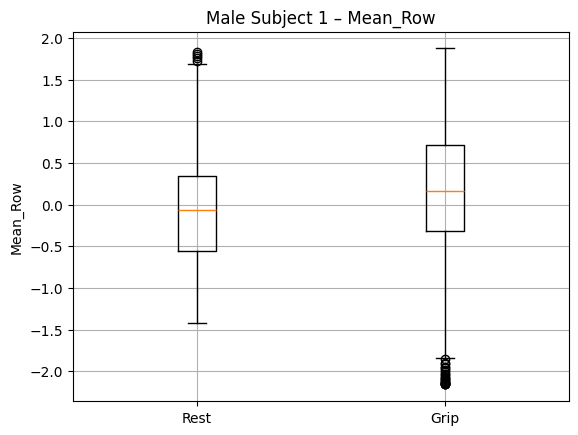

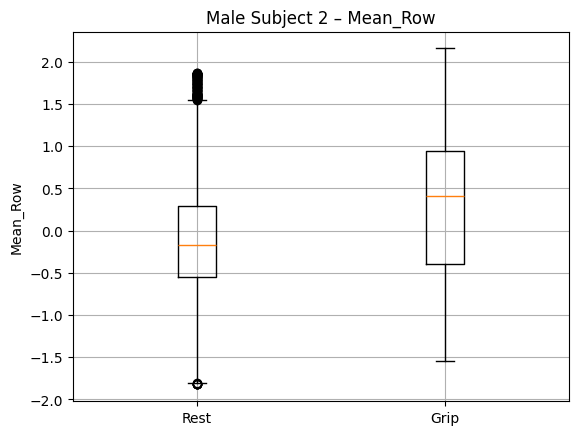

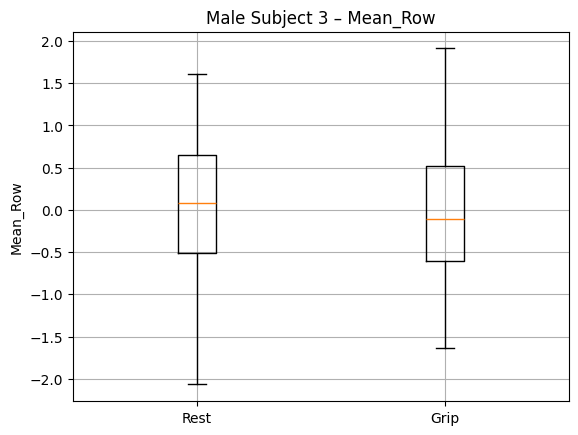

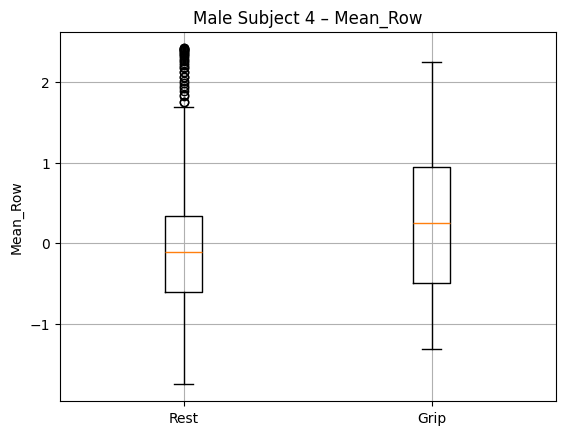

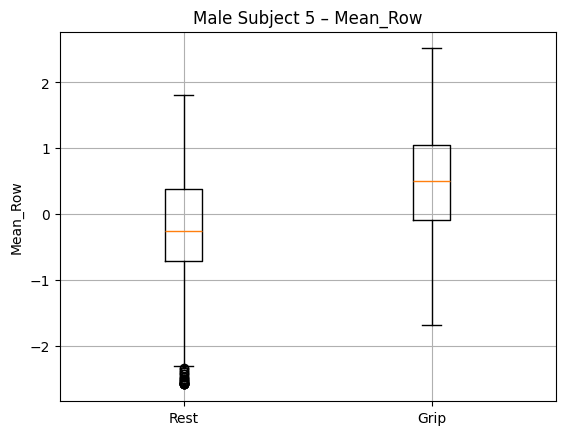

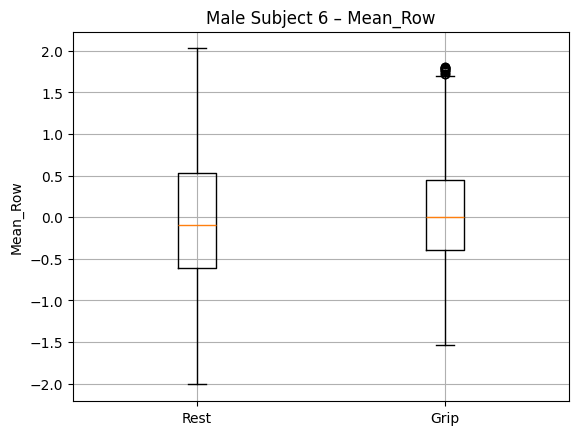

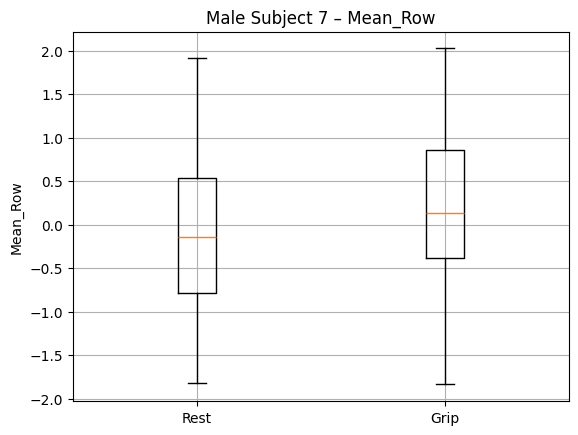

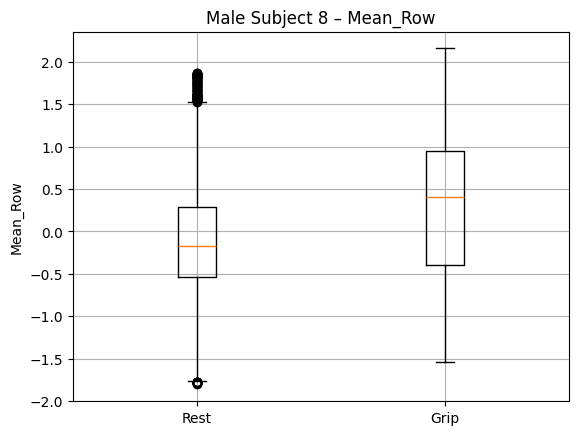

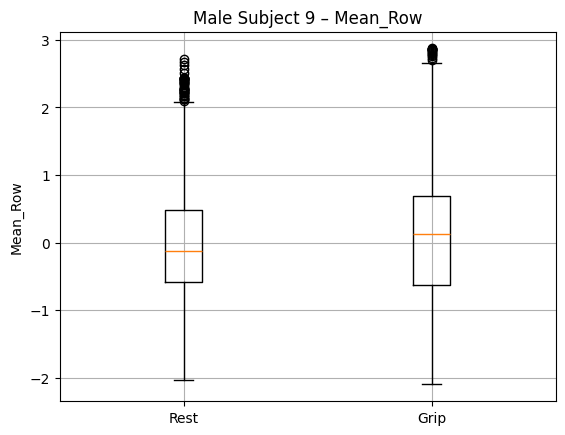

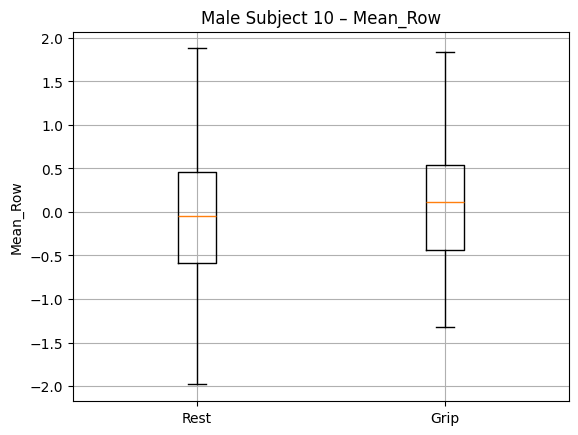

In [22]:
import matplotlib.pyplot as plt
import numpy as np

rows_per_subject = 3448

# ✅ Only male rows
male_df = final_dataset[final_dataset["Gender"] == 0].reset_index(drop=True)

for i in range(10):   # 10 male subjects
    
    start = i * rows_per_subject
    end   = (i + 1) * rows_per_subject
    
    subj_df = male_df.iloc[start:end]
    
    rest_vals = subj_df[subj_df["State"] == 0]["Mean_Row"]
    grip_vals = subj_df[subj_df["State"] == 1]["Mean_Row"]
    
    plt.figure()
    plt.boxplot([rest_vals, grip_vals])
    plt.xticks([1, 2], ["Rest", "Grip"])
    plt.title(f"Male Subject {i+1} – Mean_Row")
    plt.ylabel("Mean_Row")
    plt.grid(True)
    plt.show()


In [23]:
X = final_dataset.drop(columns=["State"])
y = final_dataset["State"]
gender = final_dataset["Gender"]


In [24]:
from sklearn.model_selection import train_test_split

# ✅ 1) First split: 60% Train | 40% Temp  (stratified by Gender)
X_train, X_temp, y_train, y_temp, gender_train, gender_temp = train_test_split(
    X, y, gender,
    test_size=0.4,
    random_state=42,
    stratify=gender
)

# ✅ 2) Second split: 20% Val | 20% Test (also stratified by Gender)
X_val, X_test, y_val, y_test, gender_val, gender_test = train_test_split(
    X_temp, y_temp, gender_temp,
    test_size=0.5,   # half of 40% → 20% & 20%
    random_state=42,
    stratify=gender_temp
)


In [25]:
print("TRAIN Gender Ratio:\n", gender_train.value_counts(normalize=True))
print("\nVAL Gender Ratio:\n", gender_val.value_counts(normalize=True))
print("\nTEST Gender Ratio:\n", gender_test.value_counts(normalize=True))


TRAIN Gender Ratio:
 Gender
0    0.5
1    0.5
Name: proportion, dtype: float64

VAL Gender Ratio:
 Gender
0    0.5
1    0.5
Name: proportion, dtype: float64

TEST Gender Ratio:
 Gender
0    0.5
1    0.5
Name: proportion, dtype: float64


In [59]:
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)


Train: (41328, 25) (41328,)
Val:   (13776, 25) (13776,)
Test:  (13776, 25) (13776,)


In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


In [61]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

svm_model.fit(X_train_scaled, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [62]:
from sklearn.metrics import accuracy_score

y_val_pred = svm_model.predict(X_val_scaled)
val_acc = accuracy_score(y_val, y_val_pred)

print("✅ Validation Accuracy:", val_acc)


✅ Validation Accuracy: 0.8307926829268293


In [63]:
from sklearn.metrics import classification_report, confusion_matrix

y_test_pred = svm_model.predict(X_test_scaled)

print("✅ Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\n✅ Classification Report:\n", classification_report(y_test, y_test_pred))
print("\n✅ Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))


✅ Test Accuracy: 0.8277439024390244

✅ Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.97      0.89      9800
           1       0.88      0.47      0.61      3976

    accuracy                           0.83     13776
   macro avg       0.85      0.72      0.75     13776
weighted avg       0.84      0.83      0.81     13776


✅ Confusion Matrix:
 [[9533  267]
 [2106 1870]]


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1, "scale"],
    "kernel": ["rbf"]
}

svm = SVC(class_weight="balanced")

grid = GridSearchCV(
    svm,
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=3,      # ✅ THIS SHOWS TRAINING LIVE
    return_train_score=True
)

grid.fit(X_train_scaled, y_train)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV 1/3] END C=0.1, gamma=0.1, kernel=rbf;, score=(train=0.762, test=0.754) total time= 4.3min
[CV 2/3] END C=0.1, gamma=0.1, kernel=rbf;, score=(train=0.763, test=0.751) total time= 4.4min
[CV 2/3] END C=0.1, gamma=0.01, kernel=rbf;, score=(train=0.645, test=0.649) total time= 4.6min
[CV 3/3] END C=0.1, gamma=0.01, kernel=rbf;, score=(train=0.654, test=0.647) total time= 4.7min
[CV 1/3] END C=0.1, gamma=0.01, kernel=rbf;, score=(train=0.650, test=0.651) total time= 4.7min
[CV 3/3] END C=0.1, gamma=0.001, kernel=rbf;, score=(train=0.666, test=0.661) total time= 4.8min
[CV 2/3] END C=0.1, gamma=0.001, kernel=rbf;, score=(train=0.658, test=0.661) total time= 4.8min
[CV 1/3] END C=0.1, gamma=0.001, kernel=rbf;, score=(train=0.658, test=0.660) total time= 4.9min
[CV 3/3] END C=0.1, gamma=0.1, kernel=rbf;, score=(train=0.763, test=0.756) total time= 5.2min
[CV 1/3] END C=0.1, gamma=scale, kernel=rbf;, score=(train=0.690, test=0.68